In [69]:
import os
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Suppress TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2"

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [70]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [72]:

continuous_features = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = train.select_dtypes(include=['object']).columns.tolist()

num_continuous = len(continuous_features)
num_categorical = len(categorical_features)

print(f"Số lượng đặc trưng liên tục: {num_continuous}")
print(f"Số lượng đặc trưng phân loại: {num_categorical}")


print("Đặc trưng liên tục:", continuous_features)
print("Đặc trưng phân loại:", categorical_features)

Số lượng đặc trưng liên tục: 38
Số lượng đặc trưng phân loại: 43
Đặc trưng liên tục: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Đặc trưng phân loại: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', '

In [73]:
# Tính số lượng và tỷ lệ phần trăm giá trị null cho từng cột
null_counts = train.isnull().sum()
null_percent = (null_counts / len(train)) * 100

# Tạo DataFrame từ các giá trị trên
null_summary = pd.DataFrame({'Null Count': null_counts, 'Null Percentage': null_percent})

# Lọc ra các cột có giá trị null
null_summary = null_summary[null_summary['Null Count'] > 0]

# Hiển thị tổng quan
print(null_summary.sort_values(by='Null Percentage', ascending=False))

              Null Count  Null Percentage
PoolQC              1453        99.520548
MiscFeature         1406        96.301370
Alley               1369        93.767123
Fence               1179        80.753425
MasVnrType           872        59.726027
FireplaceQu          690        47.260274
LotFrontage          259        17.739726
GarageType            81         5.547945
GarageYrBlt           81         5.547945
GarageFinish          81         5.547945
GarageQual            81         5.547945
GarageCond            81         5.547945
BsmtFinType2          38         2.602740
BsmtExposure          38         2.602740
BsmtFinType1          37         2.534247
BsmtCond              37         2.534247
BsmtQual              37         2.534247
MasVnrArea             8         0.547945
Electrical             1         0.068493


In [74]:
train_data= train.loc[:, train.isnull().sum()/len(train)<0.80]

x= train_data.iloc[:, 1:-1] # Dropping 'Id' and the Y feature
y= train_data.iloc[:,-1]

train_cols= x.columns
print(train_data.shape, x.shape, y.shape)

(1460, 77) (1460, 75) (1460,)


In [75]:
train_stats= x.describe().transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [76]:
ordinal_cols= list(x.columns[x.columns.str.contains('Yr|Year')])
print('ordinal/temporal columns:\n',ordinal_cols)
nominal_cols= list(set(x.select_dtypes(include=['object']).columns)- set(ordinal_cols))
print('nominal columns:\n', nominal_cols)
numeric_cols= list(set(x.select_dtypes(exclude=['object']).columns)- set(ordinal_cols))
print('numeric columns:\n',numeric_cols)

ordinal/temporal columns:
 ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']
nominal columns:
 ['RoofMatl', 'HeatingQC', 'Street', 'BsmtFinType1', 'Neighborhood', 'BsmtQual', 'KitchenQual', 'CentralAir', 'GarageFinish', 'LandContour', 'BsmtFinType2', 'FireplaceQu', 'MSZoning', 'Condition1', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'BldgType', 'Functional', 'PavedDrive', 'Foundation', 'LotConfig', 'LandSlope', 'RoofStyle', 'GarageQual', 'LotShape', 'Exterior1st', 'BsmtExposure', 'GarageCond', 'Condition2', 'GarageType', 'ExterQual', 'Heating', 'HouseStyle', 'SaleType', 'BsmtCond', 'SaleCondition', 'Electrical', 'Utilities']
numeric columns:
 ['BsmtFullBath', 'MSSubClass', 'LotFrontage', 'TotRmsAbvGrd', 'ScreenPorch', 'BedroomAbvGr', 'GrLivArea', 'OverallCond', 'GarageCars', 'FullBath', 'LowQualFinSF', 'MasVnrArea', '2ndFlrSF', 'MiscVal', 'HalfBath', 'EnclosedPorch', 'Fireplaces', 'KitchenAbvGr', 'OverallQual', 'GarageArea', 'BsmtUnfSF', 'WoodDeckSF', 'OpenPorchSF', 'TotalBsmtSF', 

In [77]:
x[nominal_cols].describe().transpose()

,count,unique,top,freq
RoofMatl,1460,8,CompShg,1434
HeatingQC,1460,5,Ex,741
Street,1460,2,Pave,1454
BsmtFinType1,1423,6,Unf,430
Neighborhood,1460,25,NAmes,225
BsmtQual,1423,4,TA,649
KitchenQual,1460,4,TA,735
CentralAir,1460,2,Y,1365
GarageFinish,1379,3,Unf,605
LandContour,1460,4,Lvl,1311


In [78]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.20, random_state=0)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1168, 75), (292, 75), (1168,), (292,))

In [79]:
def missing_val_imputation(x, ordinal_cols,nominal_cols,numeric_cols):
    
    for col in ordinal_cols:
        x.loc[:,col]= x.loc[:,col].fillna(x.loc[:,col].mean())

    x.loc[:,nominal_cols]= x.loc[:,nominal_cols].fillna("?")
    
    for col in numeric_cols:
        x.loc[:,col]= x.loc[:,col].fillna(x.loc[:,col].mean())

    print("All missing values are now imputed!\n",x.isnull().sum().sort_values(ascending=False))
    
    return x

In [80]:
x_train= missing_val_imputation(x_train,ordinal_cols,nominal_cols,numeric_cols)
x_test= missing_val_imputation(x_test,ordinal_cols,nominal_cols,numeric_cols)

All missing values are now imputed!
 MSSubClass       0
GarageType       0
Fireplaces       0
Functional       0
TotRmsAbvGrd     0
                ..
MasVnrArea       0
MasVnrType       0
Exterior2nd      0
Exterior1st      0
SaleCondition    0
Length: 75, dtype: int64
All missing values are now imputed!
 MSSubClass       0
GarageType       0
Fireplaces       0
Functional       0
TotRmsAbvGrd     0
                ..
MasVnrArea       0
MasVnrType       0
Exterior2nd      0
Exterior1st      0
SaleCondition    0
Length: 75, dtype: int64


In [81]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(x_train[nominal_cols]) 

def ohe_transform(x, ohe, nominal_cols):
    x_ohe = pd.DataFrame(ohe.transform(x[nominal_cols]))
    x_ohe.columns = ohe.get_feature_names_out(nominal_cols)  # Sử dụng get_feature_names_out

    x = x.drop(nominal_cols, axis=1)
    x.reset_index(inplace=True, drop=True)
    x = x.merge(x_ohe, left_index=True, right_index=True)
    
    return x

# Biến đổi dữ liệu
x_train = ohe_transform(x_train, ohe, nominal_cols)
x_test = ohe_transform(x_test, ohe, nominal_cols)

# Kiểm tra kích thước của các tập dữ liệu
x_train.shape, x_test.shape


((1168, 282), (292, 282))

In [82]:
from sklearn.preprocessing import StandardScaler

# Standard Scaling
ss= StandardScaler()
x_train_ss= pd.DataFrame(ss.fit_transform(x_train))
x_test_ss= pd.DataFrame(ss.transform(x_test))
x_train.shape, x_train_ss.shape, x_test_ss.shape, y_train.shape

((1168, 282), (1168, 282), (292, 282), (1168,))

In [83]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

sel= SelectFromModel(Lasso(alpha=0.5, max_iter=3000, tol=0.005, random_state=0, warm_start= False)) # warm_start= True

# train the lasso model and select features
sel.fit(x_train_ss, y_train)

sel.get_support()

selected_feats= x_train_ss.columns[(sel.get_support())]

# print the stats
print("# of total features: ",x_train.shape[1])
print("# of selected features: ",len(selected_feats))
# print("# of rejected features: ",np.sum(sel.estimator_.coef_==0))
# print('Selected features:', selected_feats)

x_train_ss= x_train_ss[selected_feats]
x_test_ss= x_test_ss[selected_feats]

x_train_ss.shape, x_test_ss.shape

# of total features:  282
# of selected features:  262


((1168, 262), (292, 262))

In [86]:
# Building a neural network
import keras

optimizer= tf.keras.optimizers.Adam(0.001)

normal_model = Sequential()
normal_model.add(Dense(128, input_shape=[len(x_train_ss.keys())], kernel_initializer='normal', activation='relu'))
normal_model.add(Dense(64, kernel_initializer='normal', activation='relu'))
normal_model.add(Dense(32, kernel_initializer='normal', activation='relu'))
normal_model.add(Dense(1, kernel_initializer='normal'))
normal_model.compile(loss='mse', optimizer = optimizer, metrics=['mean_absolute_error','mean_squared_error'])

# Build and inspect the model

normal_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │        33,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,033 (172.00 KB)

 Trainable params: 44,033 (172.00 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, verbose=1, mode='min', restore_best_weights=False)

history= normal_model.fit(
    x_train_ss, y_train,
    epochs=200,
    validation_data=(x_test_ss, y_test),
    verbose=0, #set verbose=1 for full details at every epoch
    callbacks= [early_stopping_cb])

loss, mae, mse= normal_model.evaluate(x_test_ss, y_test, verbose=2)

print("Test-set Mean absolute error: {:5.2f}".format(mae))

Epoch 70: early stopping
10/10 - 0s - 2ms/step - loss: 3879731712.0000 - mean_absolute_error: 29878.1914 - mean_squared_error: 3879731712.0000
Test-set Mean absolute error: 29878.19


In [88]:
loss, mae, mse= normal_model.evaluate(x_test_ss, y_test, verbose=2)

print("Test-set Mean absolute error: {:5.2f}".format(mae))

10/10 - 0s - 2ms/step - loss: 3879731712.0000 - mean_absolute_error: 29878.1914 - mean_squared_error: 3879731712.0000
Test-set Mean absolute error: 29878.19


Text(0.5, 1.0, 'Train - MAE')

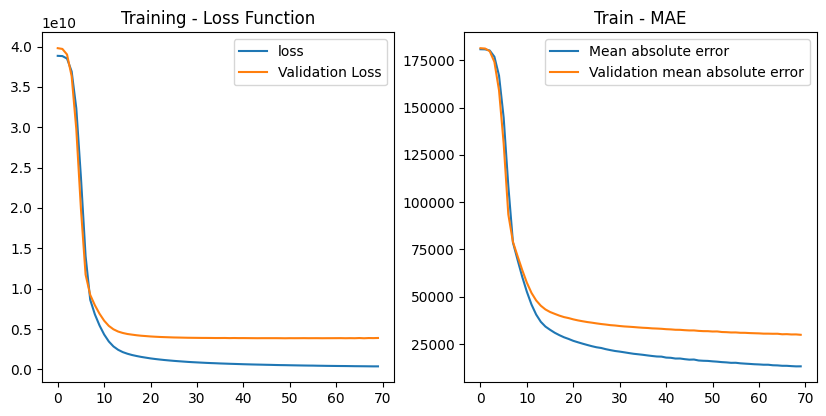

In [89]:
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training - Loss Function')

plt.subplot(2, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Mean absolute error')
plt.plot(history.history['val_mean_absolute_error'], label='Validation mean absolute error')
plt.legend()
plt.title('Train - MAE')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


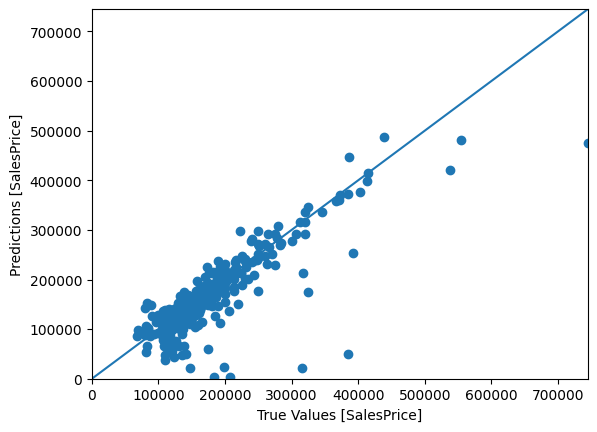

In [90]:
y_pred_test= normal_model.predict(x_test_ss).flatten()

# a = plt.axes(aspect='equal')
plt.scatter(y_test, y_pred_test)
plt.xlabel('True Values [SalesPrice]')
plt.ylabel('Predictions [SalesPrice]')

lims=[0, max(y_test)]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

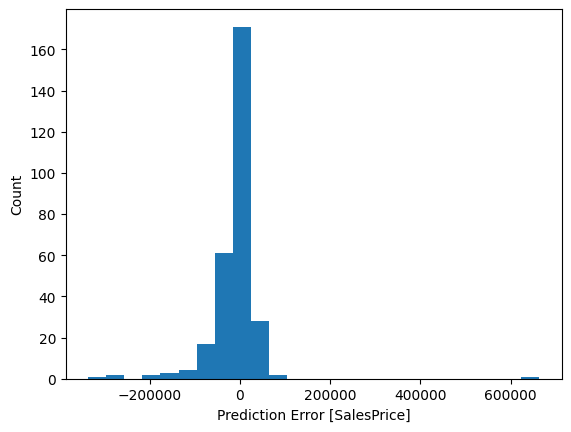

In [91]:
error= y_pred_test-y_test
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [SalesPrice]')
_=plt.ylabel('Count')